In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


In [8]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Logistic Regression Test Accuracy: 0.8582

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      6278
           1       0.90      0.81      0.85      6322

    accuracy                           0.86     12600
   macro avg       0.86      0.86      0.86     12600
weighted avg       0.86      0.86      0.86     12600

Confusion Matrix:
[[5712  566]
 [1221 5101]]


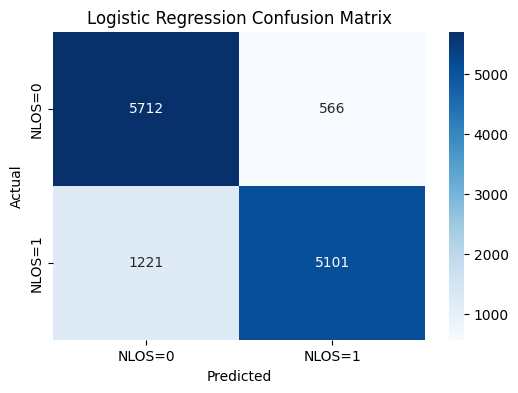

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create and train the Logistic Regression model
logreg = LogisticRegression(random_state=111, max_iter=500)
logreg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_logreg = logreg.predict(X_test)

# 3. Evaluate the performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Test Accuracy: {:.4f}".format(accuracy_logreg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

# 4. Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


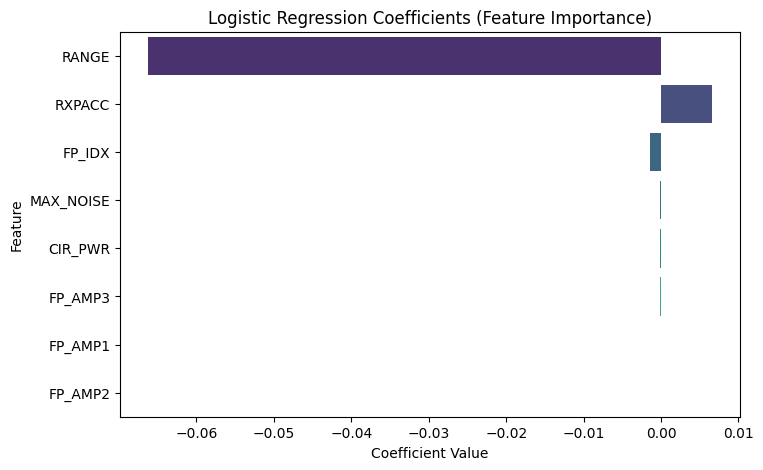

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your training features are in X_train (with the target dropped)
# If not, create a new DataFrame for feature importance analysis:
# X_train_no_target = X_train.drop(columns=["NLOS"])
# Otherwise, if X_train is already defined without "NLOS":
X_train_no_target = X_train

# Extract coefficients from the logistic regression model.
# For binary classification, logreg.coef_ returns a 2D array of shape (1, n_features)
coefficients = pd.Series(logreg.coef_[0], index=X_train_no_target.columns)

# Sort coefficients by absolute value (largest magnitude first)
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=coefficients_sorted.values, 
                 y=coefficients_sorted.index, 
                 hue=coefficients_sorted.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients (Feature Importance)")
plt.show()
